In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:

        # remove M22 
        if mouse == 22:
            continue

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day)
        _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

        gcs = load_cluster_locations(clusters_VR, cells=gcs)
        ngs = load_cluster_locations(clusters_VR, cells=ngs)
        ns = load_cluster_locations(clusters_VR, cells=ns)
        sc = load_cluster_locations(clusters_VR, cells=sc)
        ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
        all = load_cluster_locations(clusters_VR, cells=all)
        
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

    print(f'there are this many cells at the moment, {len(all_)}')

20 14
optimal travel lag is 0.2502502502502537 cm
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
20 15
optimal travel lag is 3.753753753753756 cm
there are 61 non_grid and non_spatial_cells
there are 1 grid_cells
there are 50 non grid spatial cells
there are 11 non spatial cells
there are 11 speed cells
there are 73 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
20 16
optimal travel lag is 10.860860860860868 cm
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
for the non-grid spatial cells the unique locations are ['ENTm3']
for the grid cells t

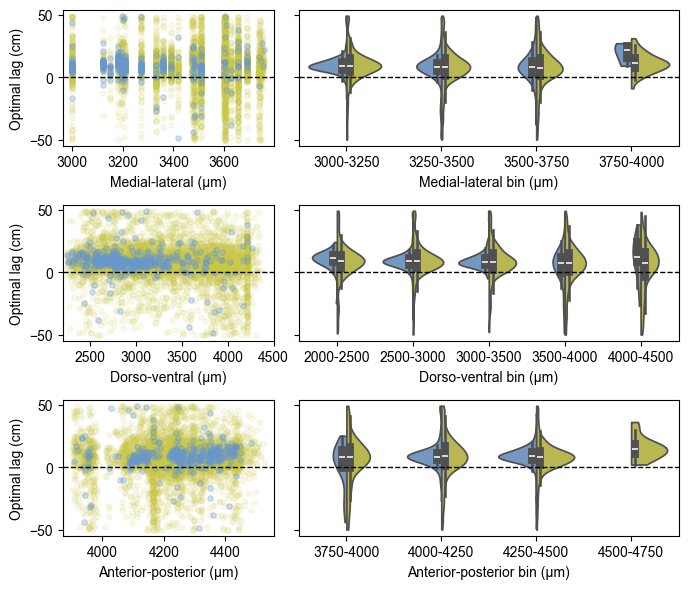

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

# Helper function to get regular bins
def get_regular_bins(series, bin_size=250):
    min_val = int(np.floor(series.min() / bin_size) * bin_size)
    max_val = int(np.ceil(series.max() / bin_size) * bin_size)
    bins = np.arange(min_val, max_val + bin_size, bin_size)
    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
    return bins, labels

# ML axis binning (250 um)
ml_series = pd.concat([(gcs_df['coord_SCs_x']*-1), (ngs_df['coord_SCs_x']*-1)])
ml_bins, ml_labels = get_regular_bins(ml_series, bin_size=250)
gcs_df['ml_bin'] = pd.cut(gcs_df['coord_SCs_x']*-1, bins=ml_bins, labels=ml_labels, include_lowest=True)
ngs_df['ml_bin'] = pd.cut(ngs_df['coord_SCs_x']*-1, bins=ml_bins, labels=ml_labels, include_lowest=True)

# DV axis binning (500 um)
dv_series = pd.concat([gcs_df['coord_SCs_y'], ngs_df['coord_SCs_y']])
dv_bins, dv_labels = get_regular_bins(dv_series, bin_size=500)
gcs_df['dv_bin'] = pd.cut(gcs_df['coord_SCs_y'], bins=dv_bins, labels=dv_labels, include_lowest=True)
ngs_df['dv_bin'] = pd.cut(ngs_df['coord_SCs_y'], bins=dv_bins, labels=dv_labels, include_lowest=True)

# AP axis binning (250 um)
ap_series = pd.concat([gcs_df['coord_SCs_z'], ngs_df['coord_SCs_z']])
ap_bins, ap_labels = get_regular_bins(ap_series, bin_size=250)
gcs_df['ap_bin'] = pd.cut(gcs_df['coord_SCs_z'], bins=ap_bins, labels=ap_labels, include_lowest=True)
ngs_df['ap_bin'] = pd.cut(ngs_df['coord_SCs_z'], bins=ap_bins, labels=ap_labels, include_lowest=True)

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Combine for violin plots
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(7, 6), width_ratios=[1,1.8], sharey='row')

# ML scatter
axes[0, 0].scatter(ngs_df['coord_SCs_x']*-1, ngs_df['optimal_travel_lag'], color='#CAC841', alpha=0.1, s=15, label='NGS')
axes[0, 0].scatter(gcs_df['coord_SCs_x']*-1, gcs_df['optimal_travel_lag'], color='#6897CD', alpha=0.3, s=15, label='GCS')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_ylabel('Optimal lag (cm)')
axes[0, 0].set_xlabel('Medial-lateral (µm)')

# ML binned violin plot
sns.violinplot(
    data=combined, 
    x='ml_bin', 
    y='optimal_travel_lag', 
    hue='group', 
    split=True, 
    palette={'GCS': '#6897CD', 'NGS': '#CAC841'}, 
    ax=axes[0, 1], 
    cut=0
)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Medial-lateral bin (µm)')
axes[0, 1].get_legend().remove()  # Remove legend from violin plot

# DV scatter
axes[1, 0].scatter(ngs_df['coord_SCs_y'], ngs_df['optimal_travel_lag'], color='#CAC841', alpha=0.1, s=15, label='NGS')
axes[1, 0].scatter(gcs_df['coord_SCs_y'], gcs_df['optimal_travel_lag'], color='#6897CD', alpha=0.3, s=15, label='GCS')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_ylabel('Optimal lag (cm)')
axes[1, 0].set_xlabel('Dorso-ventral (µm)')
axes[1, 0].set_xlim(2200, 4500)

# DV binned violin plot
sns.violinplot(
    data=combined, 
    x='dv_bin', 
    y='optimal_travel_lag', 
    hue='group', 
    split=True, 
    palette={'GCS': '#6897CD', 'NGS': '#CAC841'}, 
    ax=axes[1, 1], 
    cut=0
)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Dorso-ventral bin (µm)')
axes[1, 1].get_legend().remove()  # Remove legend from violin plot

# AP scatter
axes[2, 0].scatter(ngs_df['coord_SCs_z'], ngs_df['optimal_travel_lag'], color='#CAC841', alpha=0.1, s=15, label='NGS')
axes[2, 0].scatter(gcs_df['coord_SCs_z'], gcs_df['optimal_travel_lag'], color='#6897CD', alpha=0.3, s=15, label='GCS')
axes[2, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2, 0].set_ylabel('Optimal lag (cm)')
axes[2, 0].set_xlabel('Anterior-posterior (µm)')

# AP binned violin plot
sns.violinplot(
    data=combined, 
    x='ap_bin', 
    y='optimal_travel_lag', 
    hue='group', 
    split=True, 
    palette={'GCS': '#6897CD', 'NGS': '#CAC841'}, 
    ax=axes[2, 1], 
    cut=0
)
axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2, 1].set_xlabel('Anterior-posterior bin (µm)')
axes[2, 1].set_ylabel('Optimal lag (cm)')
axes[2, 1].get_legend().remove()  # Remove legend from violin plot

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_anatomical_axis.pdf', bbox_inches='tight')
plt.show()